## 0. Librerie, percorsi e configurazione

In [2]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 9.5 MB/s eta 0:00:01
   ------- -------------------------------- 1.8/9.6 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 6.9 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 6.5 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 7.3 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.6 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ------

Impossibile trovare il percorso specificato.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_PERMUTATIONS = 5000

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "risultati").exists():
    fallback = Path(r"C:\Users\acer\Desktop\ProgettoTesi")
    if fallback.exists():
        PROJECT_DIR = fallback

BEHAVIOR_DIR = PROJECT_DIR / "risultati" / "profilazione_acustica" / "controlli_behavioral"
BEHAVIOR_PATIENT_CSV = BEHAVIOR_DIR / "profili_comportamentali_patient_level.csv"

OUTPUT_DIR = PROJECT_DIR / "risultati" / "associazione_score_clinici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Il CSV DN4 può trovarsi nella cartella principale del progetto.
DN4_CANDIDATES = [
    PROJECT_DIR / "record_id_dn4_score.csv",
    PROJECT_DIR / "dati_clinici" / "record_id_dn4_score.csv",
    PROJECT_DIR / "risultati" / "record_id_dn4_score.csv",
]

DN4_CSV = next((p for p in DN4_CANDIDATES if p.exists()), None)

print("PROJECT_DIR:", PROJECT_DIR)
print("Profili comportamentali:", BEHAVIOR_PATIENT_CSV)
print("Esiste:", BEHAVIOR_PATIENT_CSV.exists())
print("DN4 CSV:", DN4_CSV)

if not BEHAVIOR_PATIENT_CSV.exists():
    raise FileNotFoundError(
        "Non trovo profili_comportamentali_patient_level.csv. "
        "Eseguire prima il notebook 11b fino alla sezione 8."
    )

if DN4_CSV is None:
    raise FileNotFoundError(
        "Non trovo record_id_dn4_score.csv. "
        "Copiarlo nella cartella principale del progetto oppure aggiornare DN4_CANDIDATES."
    )


PROJECT_DIR: c:\Users\acer\Desktop\ProgettoTesi
Profili comportamentali: c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\controlli_behavioral\profili_comportamentali_patient_level.csv
Esiste: True
DN4 CSV: c:\Users\acer\Desktop\ProgettoTesi\record_id_dn4_score.csv


## 1. Caricamento e controllo dei profili comportamentali

In [3]:

behavior = pd.read_csv(BEHAVIOR_PATIENT_CSV)

required_behavior = [
    "patient_id",
    "n_turns",
    "behavior_cluster_0_share",
    "behavior_cluster_1_share",
    "behavior_cluster_2_share",
]

missing = [c for c in required_behavior if c not in behavior.columns]
if missing:
    raise ValueError(f"Colonne mancanti nei profili comportamentali: {missing}")

behavior["patient_id"] = pd.to_numeric(behavior["patient_id"], errors="coerce")
behavior = behavior.dropna(subset=["patient_id"]).copy()
behavior["patient_id"] = behavior["patient_id"].astype(int)

share_cols = [
    "behavior_cluster_0_share",
    "behavior_cluster_1_share",
    "behavior_cluster_2_share",
]

for col in share_cols:
    behavior[col] = pd.to_numeric(behavior[col], errors="coerce")

behavior["share_sum"] = behavior[share_cols].sum(axis=1)

print("Pazienti:", behavior["patient_id"].nunique())
print("Righe:", len(behavior))
print("Duplicati patient_id:", int(behavior["patient_id"].duplicated().sum()))
print("Missing nelle quote:")
display(behavior[share_cols].isna().sum().to_frame("n_missing"))

print("\nControllo somma delle tre quote:")
display(behavior["share_sum"].describe().to_frame())

if behavior["patient_id"].duplicated().any():
    raise RuntimeError("I profili comportamentali devono avere una sola riga per paziente.")

if not np.allclose(behavior["share_sum"], 1.0, atol=1e-6):
    print("ATTENZIONE: alcune quote non sommano esattamente a 1.")

display(behavior[required_behavior].head())


Pazienti: 90
Righe: 90
Duplicati patient_id: 0
Missing nelle quote:


,n_missing
behavior_cluster_0_share,0
behavior_cluster_1_share,0
behavior_cluster_2_share,0



Controllo somma delle tre quote:


,share_sum
count,9.000000e+01
mean,1.000000e+00
std,9.414672e-17
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


,patient_id,n_turns,behavior_cluster_0_share,behavior_cluster_1_share,behavior_cluster_2_share
0,1,34,0.382353,0.617647,0.000000
1,2,33,0.090909,0.666667,0.242424
2,3,28,0.178571,0.750000,0.071429
3,4,32,0.000000,0.312500,0.687500
4,10,22,0.000000,0.727273,0.272727


## 2. Caricamento e controllo del DN4

In [4]:

dn4 = pd.read_csv(DN4_CSV)

required_dn4 = ["record_id", "dn4_score"]
missing = [c for c in required_dn4 if c not in dn4.columns]
if missing:
    raise ValueError(f"Colonne DN4 mancanti: {missing}")

dn4["record_id"] = pd.to_numeric(dn4["record_id"], errors="coerce")
dn4["dn4_score"] = pd.to_numeric(dn4["dn4_score"], errors="coerce")

dn4 = dn4.dropna(subset=["record_id"]).copy()
dn4["record_id"] = dn4["record_id"].astype(int)

print("Righe DN4:", len(dn4))
print("ID DN4 distinti:", dn4["record_id"].nunique())
print("Duplicati record_id:", int(dn4["record_id"].duplicated().sum()))
print("DN4 score mancanti:", int(dn4["dn4_score"].isna().sum()))

display(dn4["dn4_score"].describe().to_frame())

if dn4["record_id"].duplicated().any():
    dup = dn4.loc[dn4["record_id"].duplicated(keep=False), ["record_id", "dn4_score"]]
    display(dup.sort_values("record_id"))
    raise RuntimeError("Sono presenti record_id duplicati nel file DN4: verificare prima del merge.")


Righe DN4: 243
ID DN4 distinti: 243
Duplicati record_id: 0
DN4 score mancanti: 4


,dn4_score
count,239.000000
mean,3.468619
std,2.673803
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,9.000000


## 3. Merge patient-level profili comportamentali ↔ DN4

In [5]:

clinical = behavior.merge(
    dn4,
    left_on="patient_id",
    right_on="record_id",
    how="left",
    validate="one_to_one",
    indicator=True,
)

print("Righe dopo il merge:", len(clinical))
print("Pazienti distinti:", clinical["patient_id"].nunique())

print("\nEsito del merge:")
display(clinical["_merge"].value_counts(dropna=False).to_frame("n"))

missing_dn4_patients = clinical.loc[
    clinical["dn4_score"].isna(),
    ["patient_id", "n_turns", "_merge"]
].copy()

print("\nPazienti senza DN4 score:", len(missing_dn4_patients))
if len(missing_dn4_patients):
    display(missing_dn4_patients)

analysis_dn4 = clinical.dropna(subset=["dn4_score"]).copy()

print("\nPazienti utilizzabili per DN4:", len(analysis_dn4))
print("DN4 min/max:",
      float(analysis_dn4["dn4_score"].min()),
      float(analysis_dn4["dn4_score"].max()))

display(
    analysis_dn4[
        ["patient_id", "n_turns", *share_cols, "dn4_score"]
    ].head()
)

OUT_MERGED = OUTPUT_DIR / "profili_comportamentali_con_dn4.csv"
analysis_dn4.to_csv(OUT_MERGED, index=False)
print("\nSalvato:", OUT_MERGED)


Righe dopo il merge: 90
Pazienti distinti: 90

Esito del merge:


,n
_merge,
both,90
left_only,0
right_only,0



Pazienti senza DN4 score: 0

Pazienti utilizzabili per DN4: 90
DN4 min/max: 0.0 9.0


,patient_id,n_turns,behavior_cluster_0_share,behavior_cluster_1_share,behavior_cluster_2_share,dn4_score
0,1,34,0.382353,0.617647,0.000000,1.0
1,2,33,0.090909,0.666667,0.242424,0.0
2,3,28,0.178571,0.750000,0.071429,7.0
3,4,32,0.000000,0.312500,0.687500,7.0
4,10,22,0.000000,0.727273,0.272727,4.0



Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\profili_comportamentali_con_dn4.csv



## CHECKPOINT 1

**Fermarsi qui alla prima esecuzione.**

Inviare questi output:
1. numero di pazienti nei profili comportamentali;
2. duplicati `patient_id`;
3. descrizione di `share_sum`;
4. righe/ID distinti/duplicati/missing del DN4;
5. esito del merge;
6. numero di pazienti utilizzabili per DN4.

Solo dopo aver verificato che il merge sia corretto si procede alle associazioni statistiche.


## 4. Distribuzione del DN4 e dei profili comportamentali

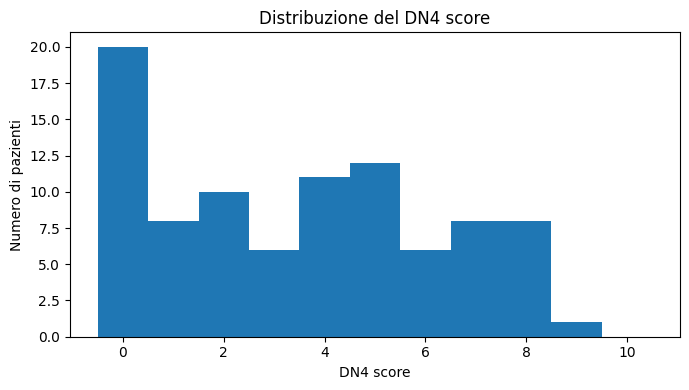

,count,mean,std,min,25%,50%,75%,max
dn4_score,90.0,3.5000,2.7570,0.0000,1.0000,4.0000,5.7500,9.0000
behavior_cluster_0_share,90.0,0.1369,0.1226,0.0000,0.0274,0.1058,0.2137,0.4364
behavior_cluster_1_share,90.0,0.6402,0.1878,0.1549,0.4957,0.6333,0.7864,1.0000
behavior_cluster_2_share,90.0,0.2228,0.1623,0.0000,0.1089,0.1800,0.3316,0.7042


In [6]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(analysis_dn4["dn4_score"], bins=np.arange(-0.5, 11.5, 1))
ax.set_xlabel("DN4 score")
ax.set_ylabel("Numero di pazienti")
ax.set_title("Distribuzione del DN4 score")
plt.tight_layout()
plt.show()

display(
    analysis_dn4[
        ["dn4_score", *share_cols]
    ].describe().T.round(4)
)



## 5. Correlazioni di Spearman: quote comportamentali ↔ DN4

Il DN4 è uno score discreto 0–10 e le quote dei cluster possono essere asimmetriche; per questo viene usata la correlazione di **Spearman**.

Le tre quote sommano a 1, quindi i tre test non rappresentano predittori indipendenti.  
Questa analisi è soprattutto **descrittiva/esplorativa**.

Viene applicata anche la correzione FDR Benjamini–Hochberg ai tre p-value.


In [7]:

corr_rows = []

for feature in share_cols:
    temp = analysis_dn4[[feature, "dn4_score"]].dropna()
    rho, p = spearmanr(temp[feature], temp["dn4_score"])
    corr_rows.append({
        "feature": feature,
        "n": len(temp),
        "spearman_rho": float(rho),
        "p_value": float(p),
    })

corr_dn4 = pd.DataFrame(corr_rows)

reject, p_fdr, _, _ = multipletests(
    corr_dn4["p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

corr_dn4["p_fdr_bh"] = p_fdr
corr_dn4["significant_fdr_0.05"] = reject

display(corr_dn4.round(4))

OUT_CORR = OUTPUT_DIR / "correlazioni_spearman_profili_dn4.csv"
corr_dn4.to_csv(OUT_CORR, index=False)
print("Salvato:", OUT_CORR)


,feature,n,spearman_rho,p_value,p_fdr_bh,significant_fdr_0.05
0,behavior_cluster_0_share,90,0.0575,0.5902,0.7299,False
1,behavior_cluster_1_share,90,-0.0581,0.5866,0.7299,False
2,behavior_cluster_2_share,90,0.0369,0.7299,0.7299,False


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\correlazioni_spearman_profili_dn4.csv


## 6. Scatter plot patient-level

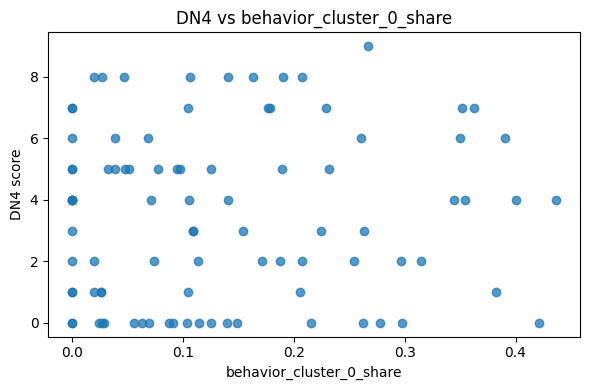

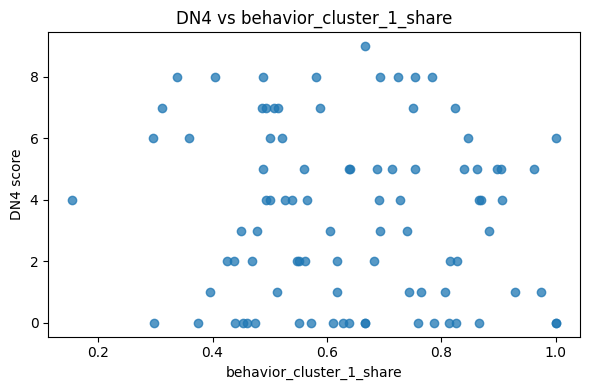

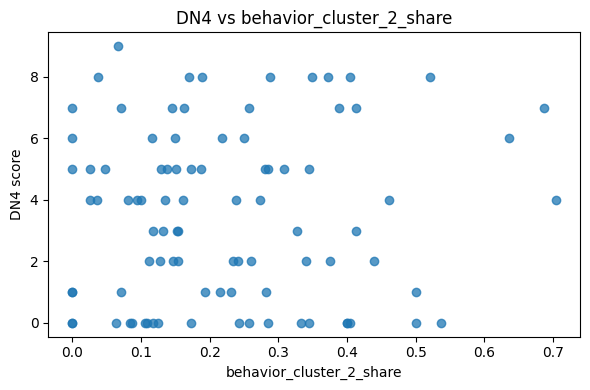

In [8]:

for feature in share_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(analysis_dn4[feature], analysis_dn4["dn4_score"], alpha=0.75)
    ax.set_xlabel(feature)
    ax.set_ylabel("DN4 score")
    ax.set_title(f"DN4 vs {feature}")
    plt.tight_layout()
    plt.show()



## 7. Modello multivariato esplorativo

Poiché:

`cluster_0_share + cluster_1_share + cluster_2_share = 1`

non è possibile inserire contemporaneamente tutte e tre le quote insieme all'intercetta.

Si usa quindi **cluster 1 come profilo di riferimento** e si stima:

- quota cluster 0;
- quota cluster 2.

I coefficienti indicano come cambia il DN4 quando aumenta la quota di quel profilo **rispetto al cluster 1**, mantenendo costante l'altra quota.

Si usano errori standard robusti HC3.


In [9]:

model_cols = [
    "behavior_cluster_0_share",
    "behavior_cluster_2_share",
]

model_df = analysis_dn4[["dn4_score", *model_cols]].dropna().copy()

X = sm.add_constant(model_df[model_cols])
y = model_df["dn4_score"]

ols_model = sm.OLS(y, X).fit(cov_type="HC3")

print(ols_model.summary())

coef_table = pd.DataFrame({
    "term": ols_model.params.index,
    "coefficient": ols_model.params.values,
    "std_error_HC3": ols_model.bse.values,
    "p_value": ols_model.pvalues.values,
    "ci95_low": ols_model.conf_int()[0].values,
    "ci95_high": ols_model.conf_int()[1].values,
})

display(coef_table.round(4))

OUT_MODEL = OUTPUT_DIR / "regressione_dn4_quote_comportamentali_HC3.csv"
coef_table.to_csv(OUT_MODEL, index=False)
print("R²:", round(float(ols_model.rsquared), 4))
print("R² adjusted:", round(float(ols_model.rsquared_adj), 4))
print("Salvato:", OUT_MODEL)


                            OLS Regression Results                            
Dep. Variable:              dn4_score   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.3591
Date:                Mon, 10 Aug 2026   Prob (F-statistic):              0.699
Time:                        09:28:56   Log-Likelihood:                -218.14
No. Observations:                  90   AIC:                             442.3
Df Residuals:                      87   BIC:                             449.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

,term,coefficient,std_error_HC3,p_value,ci95_low,ci95_high
0,const,3.0499,0.6044,0.0000,1.8653,4.2346
1,behavior_cluster_0_share,1.6139,2.2895,0.4809,-2.8734,6.1013
2,behavior_cluster_2_share,1.0279,1.9421,0.5966,-2.7786,4.8344


R²: 0.0075
R² adjusted: -0.0153
Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\regressione_dn4_quote_comportamentali_HC3.csv



## 8. Permutation test dell'associazione complessiva

Per evitare di affidarsi solo alle assunzioni del modello lineare, viene eseguito un test di permutazione:

- le quote comportamentali restano fisse;
- il DN4 viene permutato tra i pazienti;
- a ogni permutazione si ricalcola l'R²;
- il p-value indica quanto spesso un R² casuale è almeno pari a quello osservato.

Questa è una verifica esplorativa dell'associazione complessiva tra profili comportamentali e DN4.


R² osservato: 0.0075
R² medio nullo: 0.0226
95° percentile nullo: 0.0671
Permutation p-value: 0.7219


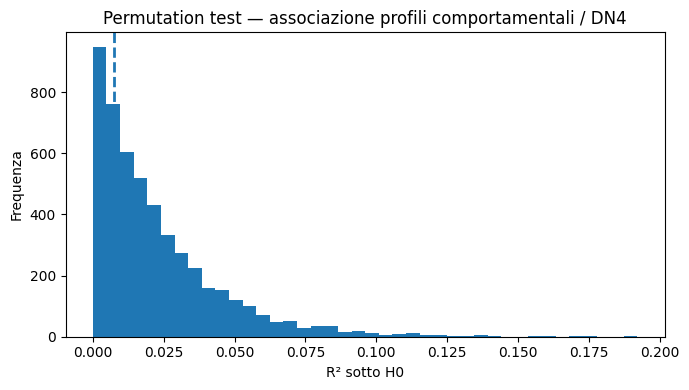

Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\permutation_test_dn4_profili_comportamentali.csv


In [11]:

rng = np.random.default_rng(RANDOM_STATE)

observed_r2 = float(ols_model.rsquared)
null_r2 = np.empty(N_PERMUTATIONS, dtype=float)

X_np = X.to_numpy()
y_np = y.to_numpy()

for i in range(N_PERMUTATIONS):
    y_perm = rng.permutation(y_np)
    perm_model = sm.OLS(y_perm, X_np).fit()
    null_r2[i] = float(perm_model.rsquared)

p_perm = (1 + np.sum(null_r2 >= observed_r2)) / (N_PERMUTATIONS + 1)

print("R² osservato:", round(observed_r2, 4))
print("R² medio nullo:", round(float(null_r2.mean()), 4))
print("95° percentile nullo:", round(float(np.quantile(null_r2, 0.95)), 4))
print("Permutation p-value:", round(float(p_perm), 4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_r2, bins=40)
ax.axvline(observed_r2, linestyle="--", linewidth=2)
ax.set_xlabel("R² sotto H0")
ax.set_ylabel("Frequenza")
ax.set_title("Permutation test — associazione profili comportamentali / DN4")
plt.tight_layout()
plt.show()

perm_summary = pd.DataFrame([{
    "n_permutations": N_PERMUTATIONS,
    "observed_r2": observed_r2,
    "null_mean_r2": float(null_r2.mean()),
    "null_r2_95th": float(np.quantile(null_r2, 0.95)),
    "permutation_p_value": float(p_perm),
}])

OUT_PERM = OUTPUT_DIR / "permutation_test_dn4_profili_comportamentali.csv"
perm_summary.to_csv(OUT_PERM, index=False)
print("Salvato:", OUT_PERM)


9.1 - DNA binario: costruzione della label

In [14]:
analysis_dn4_bin = analysis_dn4.copy()

# Label già utilizzata nella precedente analisi DN4:
# 0 = DN4 < 4
# 1 = DN4 >= 4
analysis_dn4_bin["dn4_binary"] = (
    analysis_dn4_bin["dn4_score"] >= 4
).astype(int)

class_counts = (
    analysis_dn4_bin["dn4_binary"]
    .value_counts()
    .sort_index()
    .rename(index={0: "DN4 < 4", 1: "DN4 >= 4"})
)

class_percent = (
    analysis_dn4_bin["dn4_binary"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={0: "DN4 < 4", 1: "DN4 >= 4"})
)

print("Distribuzione DN4 binario:")
display(
    pd.DataFrame({
        "n_pazienti": class_counts,
        "percentuale": class_percent
    }).round(2)
)

print("\nTotale pazienti:", len(analysis_dn4_bin))

Distribuzione DN4 binario:


,n_pazienti,percentuale
dn4_binary,,
DN4 < 4,44,48.89
DN4 >= 4,46,51.11



Totale pazienti: 90


9.2 - Confronto dei profili comportamentali tra DNA <4 e DNA >=4

In [15]:
from scipy.stats import mannwhitneyu

comparison_rows = []

for feature in share_cols:
    
    group_0 = analysis_dn4_bin.loc[
        analysis_dn4_bin["dn4_binary"] == 0, feature
    ].dropna()

    group_1 = analysis_dn4_bin.loc[
        analysis_dn4_bin["dn4_binary"] == 1, feature
    ].dropna()

    stat, p = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    comparison_rows.append({
        "feature": feature,
        "n_dn4_lt4": len(group_0),
        "median_dn4_lt4": group_0.median(),
        "n_dn4_ge4": len(group_1),
        "median_dn4_ge4": group_1.median(),
        "mannwhitney_U": stat,
        "p_value": p
    })

mw_dn4 = pd.DataFrame(comparison_rows)

# Correzione FDR sui 3 confronti
reject, p_fdr, _, _ = multipletests(
    mw_dn4["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

mw_dn4["p_fdr_bh"] = p_fdr
mw_dn4["significant_fdr_0.05"] = reject

display(mw_dn4.round(4))

OUT_MW = OUTPUT_DIR / "mannwhitney_profili_dn4_binario.csv"
mw_dn4.to_csv(OUT_MW, index=False)

print("Salvato:", OUT_MW)

,feature,n_dn4_lt4,median_dn4_lt4,n_dn4_ge4,median_dn4_ge4,mannwhitney_U,p_value,p_fdr_bh,significant_fdr_0.05
0,behavior_cluster_0_share,44,0.1087,46,0.1049,1004.5,0.9548,0.9903,False
1,behavior_cluster_1_share,44,0.6234,46,0.6395,1010.0,0.9903,0.9903,False
2,behavior_cluster_2_share,44,0.2046,46,0.1713,1047.5,0.7775,0.9903,False


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\mannwhitney_profili_dn4_binario.csv


9.3 — DN4 binario: regressione logistica patient-level con 5-fold stratified cross-validation

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

X_bin = analysis_dn4_bin[
    [
        "behavior_cluster_0_share",
        "behavior_cluster_2_share"
    ]
].copy()

y_bin = analysis_dn4_bin["dn4_binary"].copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

pipeline_bin = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# Predizioni out-of-fold
y_pred = cross_val_predict(
    pipeline_bin,
    X_bin,
    y_bin,
    cv=cv,
    method="predict"
)

y_prob = cross_val_predict(
    pipeline_bin,
    X_bin,
    y_bin,
    cv=cv,
    method="predict_proba"
)[:, 1]

acc = accuracy_score(y_bin, y_pred)
bal_acc = balanced_accuracy_score(y_bin, y_pred)
precision = precision_score(y_bin, y_pred, zero_division=0)
sensitivity = recall_score(y_bin, y_pred, pos_label=1)
specificity = recall_score(y_bin, y_pred, pos_label=0)
f1 = f1_score(y_bin, y_pred, zero_division=0)
auc = roc_auc_score(y_bin, y_prob)

cm = confusion_matrix(y_bin, y_pred)

print("Confusion matrix:")
print(cm)

print("\nMetriche 5-fold CV:")
print("Accuracy:", round(acc, 4))
print("Balanced accuracy:", round(bal_acc, 4))
print("Sensitivity:", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))
print("Precision:", round(precision, 4))
print("F1:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

metrics_bin = pd.DataFrame([{
    "accuracy": acc,
    "balanced_accuracy": bal_acc,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "f1": f1,
    "roc_auc": auc
}])

OUT_LOG = OUTPUT_DIR / "classificazione_dn4_binario_profili_comportamentali.csv"
metrics_bin.to_csv(OUT_LOG, index=False)

print("\nSalvato:", OUT_LOG)

Confusion matrix:
[[14 30]
 [28 18]]

Metriche 5-fold CV:
Accuracy: 0.3556
Balanced accuracy: 0.3547
Sensitivity: 0.3913
Specificity: 0.3182
Precision: 0.375
F1: 0.383
ROC-AUC: 0.3293

Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\classificazione_dn4_binario_profili_comportamentali.csv


9.4 — DN4 binario: metriche separate per fold

In [17]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

fold_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(
    cv.split(X_bin, y_bin), start=1
):
    X_train = X_bin.iloc[train_idx]
    X_test = X_bin.iloc[test_idx]
    y_train = y_bin.iloc[train_idx]
    y_test = y_bin.iloc[test_idx]

    model = clone(pipeline_bin)
    model.fit(X_train, y_train)

    y_prob_fold = model.predict_proba(X_test)[:, 1]
    y_pred_fold = model.predict(X_test)

    fold_rows.append({
        "fold": fold_idx,
        "n_test": len(test_idx),
        "roc_auc": roc_auc_score(y_test, y_prob_fold),
        "balanced_accuracy": balanced_accuracy_score(
            y_test, y_pred_fold
        )
    })

fold_metrics = pd.DataFrame(fold_rows)

display(fold_metrics.round(4))

print(
    "\nROC-AUC media:",
    round(fold_metrics["roc_auc"].mean(), 4)
)

print(
    "ROC-AUC std:",
    round(fold_metrics["roc_auc"].std(), 4)
)

print(
    "Balanced accuracy media:",
    round(fold_metrics["balanced_accuracy"].mean(), 4)
)

print(
    "Balanced accuracy std:",
    round(fold_metrics["balanced_accuracy"].std(), 4)
)

,fold,n_test,roc_auc,balanced_accuracy
0,1,18,0.2716,0.3333
1,2,18,0.3210,0.3333
2,3,18,0.3951,0.4444
3,4,18,0.3333,0.3333
4,5,18,0.2812,0.3250



ROC-AUC media: 0.3204
ROC-AUC std: 0.0491
Balanced accuracy media: 0.3539
Balanced accuracy std: 0.0508


9.5 — Permutation test della ROC-AUC media
DN4 binario / profili comportamentali

ROC-AUC media osservata: 0.3204
ROC-AUC media sotto H0: 0.5044
Dev. std. sotto H0: 0.0885
5° percentile H0: 0.3475
95° percentile H0: 0.6357

p-value modello migliore del caso: 0.98
p-value AUC così bassa o inferiore: 0.021
p-value bilaterale: 0.042


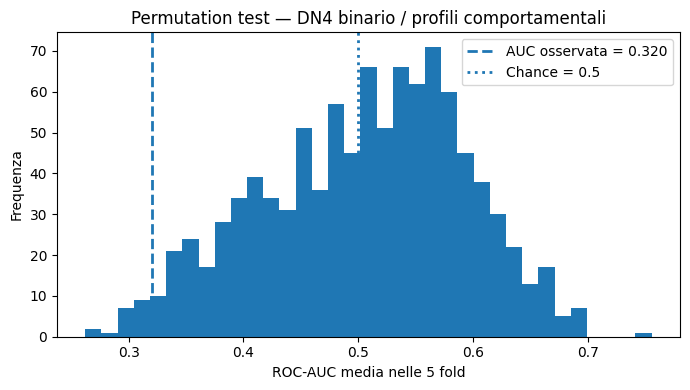


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\permutation_test_dn4_binario_profili_comportamentali.csv


In [18]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

N_PERM_BIN = 1000
rng = np.random.default_rng(RANDOM_STATE)

# Manteniamo esattamente le stesse 5 fold usate nell'analisi reale
fixed_splits = list(cv.split(X_bin, y_bin))

observed_mean_auc = fold_metrics["roc_auc"].mean()

null_mean_auc = []

while len(null_mean_auc) < N_PERM_BIN:

    y_perm = pd.Series(
        rng.permutation(y_bin.to_numpy()),
        index=y_bin.index
    )

    aucs_perm = []
    valid_perm = True

    for train_idx, test_idx in fixed_splits:

        X_train = X_bin.iloc[train_idx]
        X_test = X_bin.iloc[test_idx]

        y_train = y_perm.iloc[train_idx]
        y_test = y_perm.iloc[test_idx]

        # Controllo di sicurezza
        if y_train.nunique() < 2 or y_test.nunique() < 2:
            valid_perm = False
            break

        model = clone(pipeline_bin)
        model.fit(X_train, y_train)

        y_prob_perm = model.predict_proba(X_test)[:, 1]

        aucs_perm.append(
            roc_auc_score(y_test, y_prob_perm)
        )

    if valid_perm:
        null_mean_auc.append(np.mean(aucs_perm))


null_mean_auc = np.asarray(null_mean_auc)

# Test principale:
# il modello reale è migliore di quanto atteso casualmente?
p_better = (
    1 + np.sum(null_mean_auc >= observed_mean_auc)
) / (len(null_mean_auc) + 1)

# Controllo diagnostico:
# quanto è raro ottenere casualmente un'AUC così bassa?
p_lower = (
    1 + np.sum(null_mean_auc <= observed_mean_auc)
) / (len(null_mean_auc) + 1)

# Test bilaterale rispetto alla distribuzione nulla
p_two_sided = min(
    1.0,
    2 * min(p_better, p_lower)
)

print("ROC-AUC media osservata:", round(observed_mean_auc, 4))
print("ROC-AUC media sotto H0:", round(null_mean_auc.mean(), 4))
print("Dev. std. sotto H0:", round(null_mean_auc.std(), 4))
print("5° percentile H0:", round(np.quantile(null_mean_auc, 0.05), 4))
print("95° percentile H0:", round(np.quantile(null_mean_auc, 0.95), 4))

print("\np-value modello migliore del caso:", round(p_better, 4))
print("p-value AUC così bassa o inferiore:", round(p_lower, 4))
print("p-value bilaterale:", round(p_two_sided, 4))


# Grafico
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(null_mean_auc, bins=35)

ax.axvline(
    observed_mean_auc,
    linestyle="--",
    linewidth=2,
    label=f"AUC osservata = {observed_mean_auc:.3f}"
)

ax.axvline(
    0.5,
    linestyle=":",
    linewidth=2,
    label="Chance = 0.5"
)

ax.set_xlabel("ROC-AUC media nelle 5 fold")
ax.set_ylabel("Frequenza")
ax.set_title(
    "Permutation test — DN4 binario / profili comportamentali"
)

ax.legend()

plt.tight_layout()
plt.show()


perm_bin_summary = pd.DataFrame([{
    "n_permutations": N_PERM_BIN,
    "observed_mean_auc": observed_mean_auc,
    "null_mean_auc": null_mean_auc.mean(),
    "null_std_auc": null_mean_auc.std(),
    "null_auc_5th": np.quantile(null_mean_auc, 0.05),
    "null_auc_95th": np.quantile(null_mean_auc, 0.95),
    "p_better_than_random": p_better,
    "p_lower_than_observed": p_lower,
    "p_two_sided": p_two_sided
}])

OUT_PERM_BIN = (
    OUTPUT_DIR /
    "permutation_test_dn4_binario_profili_comportamentali.csv"
)

perm_bin_summary.to_csv(
    OUT_PERM_BIN,
    index=False
)

print("\nSalvato:", OUT_PERM_BIN)

9.6 — Robustezza rispetto alla partizione:Repeated Stratified 5-fold Cross-Validation

Numero totale fold: 100

ROC-AUC:
Media: 0.3821
Std: 0.1038
Mediana: 0.3765
5° percentile: 0.2249
95° percentile: 0.5683
% fold con AUC > 0.5: 13.0

Balanced Accuracy:
Media: 0.4092
Std: 0.093
Mediana: 0.3889


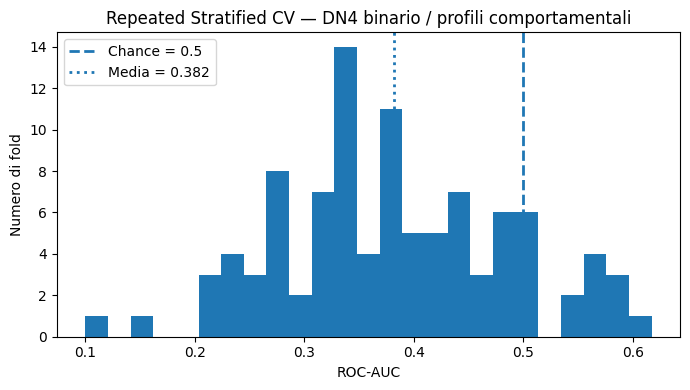


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\repeated_cv_dn4_binario_profili_comportamentali.csv


In [19]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_validate

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=RANDOM_STATE
)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy"
}

cv_repeated_results = cross_validate(
    pipeline_bin,
    X_bin,
    y_bin,
    cv=repeated_cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

auc_repeated = cv_repeated_results["test_roc_auc"]
bal_repeated = cv_repeated_results["test_balanced_accuracy"]

print("Numero totale fold:", len(auc_repeated))

print("\nROC-AUC:")
print("Media:", round(auc_repeated.mean(), 4))
print("Std:", round(auc_repeated.std(), 4))
print("Mediana:", round(np.median(auc_repeated), 4))
print("5° percentile:", round(np.quantile(auc_repeated, 0.05), 4))
print("95° percentile:", round(np.quantile(auc_repeated, 0.95), 4))
print(
    "% fold con AUC > 0.5:",
    round(100 * np.mean(auc_repeated > 0.5), 2)
)

print("\nBalanced Accuracy:")
print("Media:", round(bal_repeated.mean(), 4))
print("Std:", round(bal_repeated.std(), 4))
print("Mediana:", round(np.median(bal_repeated), 4))

# Distribuzione delle AUC sulle 100 fold
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(auc_repeated, bins=25)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="Chance = 0.5"
)

ax.axvline(
    auc_repeated.mean(),
    linestyle=":",
    linewidth=2,
    label=f"Media = {auc_repeated.mean():.3f}"
)

ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Numero di fold")
ax.set_title(
    "Repeated Stratified CV — DN4 binario / profili comportamentali"
)

ax.legend()
plt.tight_layout()
plt.show()

repeated_summary = pd.DataFrame([{
    "n_folds_total": len(auc_repeated),
    "mean_auc": auc_repeated.mean(),
    "std_auc": auc_repeated.std(),
    "median_auc": np.median(auc_repeated),
    "auc_5th": np.quantile(auc_repeated, 0.05),
    "auc_95th": np.quantile(auc_repeated, 0.95),
    "pct_auc_above_0.5": 100 * np.mean(auc_repeated > 0.5),
    "mean_balanced_accuracy": bal_repeated.mean(),
    "std_balanced_accuracy": bal_repeated.std(),
    "median_balanced_accuracy": np.median(bal_repeated)
}])

OUT_REPEATED = (
    OUTPUT_DIR /
    "repeated_cv_dn4_binario_profili_comportamentali.csv"
)

repeated_summary.to_csv(
    OUT_REPEATED,
    index=False
)

print("\nSalvato:", OUT_REPEATED)

9.7 — Diagnostica finale DN4 binario:train vs test e stabilità dei coefficienti

In [20]:
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score
)

diagnostic_rows = []

# Ogni paziente sarà nel test una volta per ripetizione.
# Accumuliamo le probabilità OOF per ottenere anche una
# previsione media robusta a livello paziente.
prob_sum = np.zeros(len(y_bin), dtype=float)
prob_count = np.zeros(len(y_bin), dtype=int)

repeated_cv_diag = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=RANDOM_STATE
)

for split_idx, (train_idx, test_idx) in enumerate(
    repeated_cv_diag.split(X_bin, y_bin),
    start=1
):

    X_train = X_bin.iloc[train_idx]
    X_test = X_bin.iloc[test_idx]

    y_train = y_bin.iloc[train_idx]
    y_test = y_bin.iloc[test_idx]

    model = clone(pipeline_bin)
    model.fit(X_train, y_train)

    prob_train = model.predict_proba(X_train)[:, 1]
    prob_test = model.predict_proba(X_test)[:, 1]

    pred_test = model.predict(X_test)

    train_auc = roc_auc_score(
        y_train,
        prob_train
    )

    test_auc = roc_auc_score(
        y_test,
        prob_test
    )

    test_bal_acc = balanced_accuracy_score(
        y_test,
        pred_test
    )

    # Coefficienti della Logistic Regression dopo scaling
    coefs = model.named_steps["logreg"].coef_[0]

    diagnostic_rows.append({
        "split": split_idx,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "test_balanced_accuracy": test_bal_acc,
        "coef_cluster_0_share": coefs[0],
        "coef_cluster_2_share": coefs[1]
    })

    prob_sum[test_idx] += prob_test
    prob_count[test_idx] += 1


diag_df = pd.DataFrame(diagnostic_rows)

print("TRAIN ROC-AUC")
print("Media:", round(diag_df["train_auc"].mean(), 4))
print("Std:", round(diag_df["train_auc"].std(), 4))

print("\nTEST ROC-AUC")
print("Media:", round(diag_df["test_auc"].mean(), 4))
print("Std:", round(diag_df["test_auc"].std(), 4))

print("\nCOEFFICIENTE CLUSTER 0")
print("Media:", round(diag_df["coef_cluster_0_share"].mean(), 4))
print("Std:", round(diag_df["coef_cluster_0_share"].std(), 4))
print(
    "% positivo:",
    round(
        100 *
        np.mean(diag_df["coef_cluster_0_share"] > 0),
        2
    )
)

print("\nCOEFFICIENTE CLUSTER 2")
print("Media:", round(diag_df["coef_cluster_2_share"].mean(), 4))
print("Std:", round(diag_df["coef_cluster_2_share"].std(), 4))
print(
    "% positivo:",
    round(
        100 *
        np.mean(diag_df["coef_cluster_2_share"] > 0),
        2
    )
)

# ============================================================
# Predizione OOF media per paziente sulle 20 ripetizioni
# ============================================================

assert np.all(prob_count == 20)

mean_oof_prob = prob_sum / prob_count

repeated_oof_auc = roc_auc_score(
    y_bin,
    mean_oof_prob
)

repeated_oof_pred = (
    mean_oof_prob >= 0.5
).astype(int)

repeated_oof_bal_acc = balanced_accuracy_score(
    y_bin,
    repeated_oof_pred
)

print("\nPREVISIONE OOF MEDIA PER PAZIENTE")
print(
    "ROC-AUC:",
    round(repeated_oof_auc, 4)
)
print(
    "Balanced accuracy:",
    round(repeated_oof_bal_acc, 4)
)

display(diag_df.head().round(4))

OUT_DIAG = (
    OUTPUT_DIR /
    "diagnostica_dn4_binario_train_test_coefficienti.csv"
)

diag_df.to_csv(
    OUT_DIAG,
    index=False
)

print("\nSalvato:", OUT_DIAG)

TRAIN ROC-AUC
Media: 0.5356
Std: 0.0256

TEST ROC-AUC
Media: 0.3821
Std: 0.1044

COEFFICIENTE CLUSTER 0
Media: 0.0783
Std: 0.1105
% positivo: 79.0

COEFFICIENTE CLUSTER 2
Media: 0.0158
Std: 0.0901
% positivo: 60.0

PREVISIONE OOF MEDIA PER PAZIENTE
ROC-AUC: 0.294
Balanced accuracy: 0.3903


,split,train_auc,test_auc,test_balanced_accuracy,coef_cluster_0_share,coef_cluster_2_share
0,1,0.5776,0.2716,0.3333,-0.0509,-0.2868
1,2,0.5382,0.3210,0.3333,0.1186,0.1620
2,3,0.5309,0.3951,0.4444,0.0898,0.1094
3,4,0.5305,0.3333,0.3333,0.0659,0.1924
4,5,0.5571,0.2812,0.3250,0.1902,-0.1304



Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_score_clinici\diagnostica_dn4_binario_train_test_coefficienti.csv


12.10 Caricamento BPI e NRS + costruzione score BPI

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path(r"C:\Users\acer\Desktop\ProgettoTesi")

print("PROJECT_DIR:", PROJECT_DIR)
print("Esiste:", PROJECT_DIR.exists())

PROJECT_DIR: C:\Users\acer\Desktop\ProgettoTesi
Esiste: True


In [7]:
BPI_FILE = PROJECT_DIR / "dati clinici" / "patient_id_bpi.csv"
NRS_FILE = PROJECT_DIR / "dati clinici" / "patient_id_nrs.csv"

bpi = pd.read_csv(BPI_FILE)
nrs = pd.read_csv(NRS_FILE)

print("BPI:", bpi.shape)
print("NRS:", nrs.shape)

print("\nPazienti BPI:", bpi["patient_id"].nunique())
print("Pazienti NRS:", nrs["patient_id"].nunique())

print("Duplicati BPI:", bpi["patient_id"].duplicated().sum())
print("Duplicati NRS:", nrs["patient_id"].duplicated().sum())

# BPI severity e interference

BPI_SEVERITY_COLS = [
    "bpi3", "bpi4", "bpi5", "bpi6"
]

BPI_INTERFERENCE_COLS = [
    "bpi9a", "bpi9b", "bpi9c", "bpi9d",
    "bpi9e", "bpi9f", "bpi9g"
]

# Richiediamo tutti gli item della sottoscala
bpi["bpi_severity"] = bpi[BPI_SEVERITY_COLS].mean(
    axis=1,
    skipna=False
)

bpi["bpi_interference"] = bpi[BPI_INTERFERENCE_COLS].mean(
    axis=1,
    skipna=False
)

print("\nBPI severity")
print(bpi["bpi_severity"].describe())

print(
    "Missing severity:",
    bpi["bpi_severity"].isna().sum()
)

print("\nBPI interference")
print(bpi["bpi_interference"].describe())

print(
    "Missing interference:",
    bpi["bpi_interference"].isna().sum()
)

# NRS: labeling indicato dal relatore

nrs["nrs_class"] = pd.cut(
    nrs["nrs"],
    bins=[-0.1, 3, 7, 10],
    labels=["basso", "medio", "alto"],
    include_lowest=True
)

print("\nDistribuzione NRS completa:")
print(
    nrs["nrs_class"]
    .value_counts()
    .reindex(["basso", "medio", "alto"])
)

# ============================================================
# Caricamento profili comportamentali patient-level
# ============================================================

BEHAVIOR_PATIENT_FILE = (
    PROJECT_DIR
    / "risultati"
    / "profilazione_acustica"
    / "controlli_behavioral"
    / "profili_comportamentali_patient_level.csv"
)

print("File profili esiste:", BEHAVIOR_PATIENT_FILE.exists())

behavior_patient = pd.read_csv(BEHAVIOR_PATIENT_FILE)

print("Shape profili:", behavior_patient.shape)
print("Pazienti:", behavior_patient["patient_id"].nunique())
print("Duplicati:", behavior_patient["patient_id"].duplicated().sum())

display(behavior_patient.head())

BPI: (243, 16)
NRS: (243, 2)

Pazienti BPI: 243
Pazienti NRS: 243
Duplicati BPI: 0
Duplicati NRS: 0

BPI severity
count    239.000000
mean       5.142259
std        2.350275
min        0.000000
25%        3.500000
50%        5.000000
75%        7.000000
max       10.000000
Name: bpi_severity, dtype: float64
Missing severity: 4

BPI interference
count    240.000000
mean       4.255952
std        2.514641
min        0.000000
25%        2.428571
50%        4.285714
75%        6.000000
max       10.000000
Name: bpi_interference, dtype: float64
Missing interference: 3

Distribuzione NRS completa:
nrs_class
basso     43
medio     99
alto     101
Name: count, dtype: int64
File profili esiste: True
Shape profili: (90, 8)
Pazienti: 90
Duplicati: 0


,patient_id,n_turns,behavior_cluster_0_share,behavior_cluster_0_count,behavior_cluster_1_share,behavior_cluster_1_count,behavior_cluster_2_share,behavior_cluster_2_count
0,1,34,0.382353,13,0.617647,21,0.000000,0
1,2,33,0.090909,3,0.666667,22,0.242424,8
2,3,28,0.178571,5,0.750000,21,0.071429,2
3,4,32,0.000000,0,0.312500,10,0.687500,22
4,10,22,0.000000,0,0.727273,16,0.272727,6


In [ ]:
# Merge profili comportamentali + NRS + BPI

# Uniformiamo il tipo degli ID
behavior_patient["patient_id"] = pd.to_numeric(
    behavior_patient["patient_id"],
    errors="coerce"
)

nrs["patient_id"] = pd.to_numeric(
    nrs["patient_id"],
    errors="coerce"
)

bpi["patient_id"] = pd.to_numeric(
    bpi["patient_id"],
    errors="coerce"
)

clinical_new = (
    behavior_patient
    .merge(
        nrs[
            [
                "patient_id",
                "nrs",
                "nrs_class"
            ]
        ],
        on="patient_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        bpi[
            [
                "patient_id",
                "bpi3",
                "bpi_severity",
                "bpi_interference"
            ]
        ],
        on="patient_id",
        how="left",
        validate="one_to_one"
    )
)

print("=== COPERTURA NEI 90 PAZIENTI AUDIO ===")

print(
    "Pazienti totali:",
    clinical_new["patient_id"].nunique()
)

print(
    "NRS disponibile:",
    clinical_new["nrs"].notna().sum()
)

print(
    "BPI severity disponibile:",
    clinical_new["bpi_severity"].notna().sum()
)

print(
    "BPI interference disponibile:",
    clinical_new["bpi_interference"].notna().sum()
)

print("\nDistribuzione NRS nei pazienti audio:")

print(
    clinical_new["nrs_class"]
    .value_counts()
    .reindex(["basso", "medio", "alto"])
)

print("\nStatistiche NRS:")
print(clinical_new["nrs"].describe())

print("\nStatistiche BPI severity:")
print(clinical_new["bpi_severity"].describe())

print("\nStatistiche BPI interference:")
print(clinical_new["bpi_interference"].describe())

=== COPERTURA NEI 90 PAZIENTI AUDIO ===
Pazienti totali: 90
NRS disponibile: 90
BPI severity disponibile: 90
BPI interference disponibile: 90

Distribuzione NRS nei pazienti audio:
nrs_class
basso    11
medio    44
alto     35
Name: count, dtype: int64

Statistiche NRS:
count    90.000000
mean      6.422222
std       2.412411
min       1.000000
25%       5.000000
50%       7.000000
75%       8.000000
max      10.000000
Name: nrs, dtype: float64

Statistiche BPI severity:
count    90.000000
mean      4.947222
std       2.132709
min       0.000000
25%       3.500000
50%       4.875000
75%       6.750000
max       9.750000
Name: bpi_severity, dtype: float64

Statistiche BPI interference:
count    90.000000
mean      3.712698
std       2.190272
min       0.000000
25%       2.178571
50%       3.714286
75%       5.428571
max       8.714286
Name: bpi_interference, dtype: float64


12.11- NRS continuo: Spearman tra quote comportamentali e NRS

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

BEHAVIOR_SHARE_COLS = [
    "behavior_cluster_0_share",
    "behavior_cluster_1_share",
    "behavior_cluster_2_share"
]

spearman_nrs_rows = []

for col in BEHAVIOR_SHARE_COLS:

    tmp = clinical_new[
        [col, "nrs"]
    ].dropna()

    rho, p = spearmanr(
        tmp[col],
        tmp["nrs"]
    )

    spearman_nrs_rows.append({
        "feature": col,
        "n": len(tmp),
        "rho_spearman": rho,
        "p_value": p
    })

spearman_nrs = pd.DataFrame(spearman_nrs_rows)

# Correzione FDR Benjamini-Hochberg
reject, p_fdr, _, _ = multipletests(
    spearman_nrs["p_value"],
    method="fdr_bh"
)

spearman_nrs["p_fdr"] = p_fdr
spearman_nrs["significant_fdr"] = reject

display(
    spearman_nrs.round(4)
)

,feature,n,rho_spearman,p_value,p_fdr,significant_fdr
0,behavior_cluster_0_share,90,0.0070,0.9478,0.9478,False
1,behavior_cluster_1_share,90,0.0613,0.5659,0.9478,False
2,behavior_cluster_2_share,90,-0.0191,0.8585,0.9478,False


12.12- NRS continuo: OLS composizionale patient-level cluster 1 come riferimento implicito

In [ ]:
import statsmodels.api as sm

ols_nrs_df = clinical_new[
    [
        "nrs",
        "behavior_cluster_0_share",
        "behavior_cluster_2_share"
    ]
].dropna()

X_nrs = ols_nrs_df[
    [
        "behavior_cluster_0_share",
        "behavior_cluster_2_share"
    ]
]

X_nrs = sm.add_constant(X_nrs)

y_nrs = ols_nrs_df["nrs"]

ols_nrs = sm.OLS(
    y_nrs,
    X_nrs
).fit(
    cov_type="HC3"
)

print(ols_nrs.summary())

print("\nR²:", round(ols_nrs.rsquared, 4))
print(
    "R² adjusted:",
    round(ols_nrs.rsquared_adj, 4)
)

                            OLS Regression Results                            
Dep. Variable:                    nrs   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.2215
Date:                Thu, 13 Aug 2026   Prob (F-statistic):              0.802
Time:                        17:15:51   Log-Likelihood:                -206.19
No. Observations:                  90   AIC:                             418.4
Df Residuals:                      87   BIC:                             425.9
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

12.13- NRS Discretizzato confronto dei profili tra basso / medio / alto

In [11]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

NRS_ORDER = ["basso", "medio", "alto"]

kw_rows = []

for col in BEHAVIOR_SHARE_COLS:

    groups = [
        clinical_new.loc[
            clinical_new["nrs_class"] == cls,
            col
        ].dropna().values
        for cls in NRS_ORDER
    ]

    H, p = kruskal(*groups)

    kw_rows.append({
        "feature": col,
        "H": H,
        "p_value": p,
        "median_basso": np.median(groups[0]),
        "median_medio": np.median(groups[1]),
        "median_alto": np.median(groups[2])
    })

kw_nrs = pd.DataFrame(kw_rows)

reject, p_fdr, _, _ = multipletests(
    kw_nrs["p_value"],
    method="fdr_bh"
)

kw_nrs["p_fdr"] = p_fdr
kw_nrs["significant_fdr"] = reject

display(kw_nrs.round(4))

,feature,H,p_value,median_basso,median_medio,median_alto,p_fdr,significant_fdr
0,behavior_cluster_0_share,0.4458,0.8002,0.1408,0.1087,0.0968,0.8002,False
1,behavior_cluster_1_share,5.9807,0.0503,0.5143,0.6771,0.6389,0.1508,False
2,behavior_cluster_2_share,3.1693,0.2050,0.3077,0.1574,0.1724,0.3075,False


12.14 - NRS basso / medio / alto: Logistic Regression multiclass 5-fold CV

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

X_nrs_cls = clinical_new[
    [
        "behavior_cluster_0_share",
        "behavior_cluster_2_share"
    ]
].copy()

y_nrs_cls = clinical_new["nrs_class"].astype(str)

cv_nrs_cls = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_nrs_cls = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            solver="lbfgs",
            random_state=42
        )
    )
])

y_pred_nrs_cls = cross_val_predict(
    pipeline_nrs_cls,
    X_nrs_cls,
    y_nrs_cls,
    cv=cv_nrs_cls,
    method="predict"
)

cm_nrs = confusion_matrix(
    y_nrs_cls,
    y_pred_nrs_cls,
    labels=NRS_ORDER
)

acc_nrs = accuracy_score(
    y_nrs_cls,
    y_pred_nrs_cls
)

bal_acc_nrs = balanced_accuracy_score(
    y_nrs_cls,
    y_pred_nrs_cls
)

macro_f1_nrs = f1_score(
    y_nrs_cls,
    y_pred_nrs_cls,
    average="macro"
)

print("Confusion matrix")
print("Ordine classi:", NRS_ORDER)
print(cm_nrs)

print("\nMetriche 5-fold CV:")
print("Accuracy:", round(acc_nrs, 4))
print("Balanced accuracy:", round(bal_acc_nrs, 4))
print("Macro-F1:", round(macro_f1_nrs, 4))

print("\nClassification report:")
print(
    classification_report(
        y_nrs_cls,
        y_pred_nrs_cls,
        labels=NRS_ORDER,
        digits=4,
        zero_division=0
    )
)

Confusion matrix
Ordine classi: ['basso', 'medio', 'alto']
[[ 6  1  4]
 [14 21  9]
 [11 15  9]]

Metriche 5-fold CV:
Accuracy: 0.4
Balanced accuracy: 0.4266
Macro-F1: 0.3733

Classification report:
              precision    recall  f1-score   support

       basso     0.1935    0.5455    0.2857        11
       medio     0.5676    0.4773    0.5185        44
        alto     0.4091    0.2571    0.3158        35

    accuracy                         0.4000        90
   macro avg     0.3901    0.4266    0.3733        90
weighted avg     0.4602    0.4000    0.4112        90



12.15 — Permutation test NRS multiclass

=== BALANCED ACCURACY ===
Osservata: 0.4266
Media H0: 0.3309
Std H0: 0.0745
95° percentile H0: 0.4538
p-value: 0.1029

=== MACRO-F1 ===
Osservata: 0.3733
Media H0: 0.2978
Std H0: 0.059
95° percentile H0: 0.4013
p-value: 0.1019


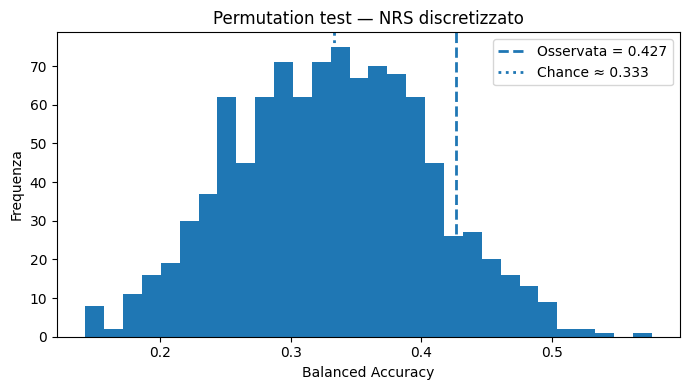

In [15]:
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, f1_score

N_PERM_NRS = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

# Valori osservati
observed_bal_acc = bal_acc_nrs
observed_macro_f1 = macro_f1_nrs

null_bal_acc = []
null_macro_f1 = []

y_original = y_nrs_cls.reset_index(drop=True)
X_original = X_nrs_cls.reset_index(drop=True)

for i in range(N_PERM_NRS):

    # Permutazione delle label mantenendo invariata
    # la distribuzione complessiva delle classi
    y_perm = pd.Series(
        rng.permutation(y_original.to_numpy())
    )

    # Ricreiamo CV stratificata sulle label permutate
    cv_perm = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    model_perm = clone(pipeline_nrs_cls)

    y_pred_perm = cross_val_predict(
        model_perm,
        X_original,
        y_perm,
        cv=cv_perm,
        method="predict"
    )

    null_bal_acc.append(
        balanced_accuracy_score(
            y_perm,
            y_pred_perm
        )
    )

    null_macro_f1.append(
        f1_score(
            y_perm,
            y_pred_perm,
            average="macro"
        )
    )


null_bal_acc = np.asarray(null_bal_acc)
null_macro_f1 = np.asarray(null_macro_f1)

# p-value: probabilità di ottenere una performance
# almeno pari a quella osservata sotto H0
p_bal_acc = (
    1 + np.sum(null_bal_acc >= observed_bal_acc)
) / (N_PERM_NRS + 1)

p_macro_f1 = (
    1 + np.sum(null_macro_f1 >= observed_macro_f1)
) / (N_PERM_NRS + 1)


print("=== BALANCED ACCURACY ===")
print("Osservata:", round(observed_bal_acc, 4))
print("Media H0:", round(null_bal_acc.mean(), 4))
print("Std H0:", round(null_bal_acc.std(), 4))
print(
    "95° percentile H0:",
    round(np.quantile(null_bal_acc, 0.95), 4)
)
print("p-value:", round(p_bal_acc, 4))


print("\n=== MACRO-F1 ===")
print("Osservata:", round(observed_macro_f1, 4))
print("Media H0:", round(null_macro_f1.mean(), 4))
print("Std H0:", round(null_macro_f1.std(), 4))
print(
    "95° percentile H0:",
    round(np.quantile(null_macro_f1, 0.95), 4)
)
print("p-value:", round(p_macro_f1, 4))


# Grafico balanced accuracy
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    null_bal_acc,
    bins=30
)

ax.axvline(
    observed_bal_acc,
    linestyle="--",
    linewidth=2,
    label=f"Osservata = {observed_bal_acc:.3f}"
)

ax.axvline(
    1/3,
    linestyle=":",
    linewidth=2,
    label="Chance ≈ 0.333"
)

ax.set_xlabel("Balanced Accuracy")
ax.set_ylabel("Frequenza")
ax.set_title(
    "Permutation test — NRS discretizzato"
)

ax.legend()

plt.tight_layout()
plt.savefig("img/Permutation test-NRS discretizzato.png", dpi=300, bbox_inches="tight")
plt.show()

12.16 — BPI continuo:Spearman profili comportamentali vs severity e interference

In [16]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

BPI_TARGETS = [
    "bpi_severity",
    "bpi_interference"
]

spearman_bpi_rows = []

for target in BPI_TARGETS:

    for col in BEHAVIOR_SHARE_COLS:

        tmp = clinical_new[
            [col, target]
        ].dropna()

        rho, p = spearmanr(
            tmp[col],
            tmp[target]
        )

        spearman_bpi_rows.append({
            "target": target,
            "feature": col,
            "n": len(tmp),
            "rho_spearman": rho,
            "p_value": p
        })

spearman_bpi = pd.DataFrame(
    spearman_bpi_rows
)

# FDR sulle 6 associazioni esplorate
reject, p_fdr, _, _ = multipletests(
    spearman_bpi["p_value"],
    method="fdr_bh"
)

spearman_bpi["p_fdr"] = p_fdr
spearman_bpi["significant_fdr"] = reject

display(
    spearman_bpi.round(4)
)

,target,feature,n,rho_spearman,p_value,p_fdr,significant_fdr
0,bpi_severity,behavior_cluster_0_share,90,0.0458,0.6684,0.6684,False
1,bpi_severity,behavior_cluster_1_share,90,0.0717,0.5019,0.6684,False
2,bpi_severity,behavior_cluster_2_share,90,-0.0852,0.4245,0.6684,False
3,bpi_interference,behavior_cluster_0_share,90,0.0976,0.3599,0.6684,False
4,bpi_interference,behavior_cluster_1_share,90,0.0490,0.6467,0.6684,False
5,bpi_interference,behavior_cluster_2_share,90,-0.0771,0.4704,0.6684,False


12.17 - BPI continuo: OLS composizionale cluster 1 = riferimento implicito

In [17]:
import statsmodels.api as sm

for target in BPI_TARGETS:

    print("\n" + "=" * 70)
    print("TARGET:", target)
    print("=" * 70)

    tmp = clinical_new[
        [
            target,
            "behavior_cluster_0_share",
            "behavior_cluster_2_share"
        ]
    ].dropna()

    X = tmp[
        [
            "behavior_cluster_0_share",
            "behavior_cluster_2_share"
        ]
    ]

    X = sm.add_constant(X)

    y = tmp[target]

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HC3"
    )

    print(model.summary())

    print(
        "\nR²:",
        round(model.rsquared, 4)
    )

    print(
        "R² adjusted:",
        round(model.rsquared_adj, 4)
    )


TARGET: bpi_severity
                            OLS Regression Results                            
Dep. Variable:           bpi_severity   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.3914
Date:                Thu, 13 Aug 2026   Prob (F-statistic):              0.677
Time:                        17:32:42   Log-Likelihood:                -194.79
No. Observations:                  90   AIC:                             395.6
Df Residuals:                      87   BIC:                             403.1
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
co

12.18 — Discretizzazione BPI

In [19]:
# BPI severity: bpi3 = worst pain
# 0-4  -> basso
# 5-6  -> medio
# 7-10 -> alto

clinical_new["bpi_severity_class"] = pd.cut(
    clinical_new["bpi3"],
    bins=[-0.1, 4, 6, 10],
    labels=["basso", "medio", "alto"],
    include_lowest=True
)

# BPI interference
# < 2      -> basso
# 2 - 5    -> medio
# > 5      -> alto

conditions = [
    clinical_new["bpi_interference"] < 2,

    (
        (clinical_new["bpi_interference"] >= 2)
        &
        (clinical_new["bpi_interference"] <= 5)
    ),

    clinical_new["bpi_interference"] > 5
]

choices = [
    "basso",
    "medio",
    "alto"
]

clinical_new["bpi_interference_class"] = np.select(
    conditions,
    choices,
    default=None
)

clinical_new["bpi_interference_class"] = pd.Categorical(
    clinical_new["bpi_interference_class"],
    categories=["basso", "medio", "alto"],
    ordered=True
)


# ------------------------------------------------------------
# Controllo distribuzioni
# ------------------------------------------------------------

print("=== BPI SEVERITY — worst pain (bpi3) ===")

print(
    clinical_new["bpi_severity_class"]
    .value_counts()
    .reindex(["basso", "medio", "alto"])
)

print("\n=== BPI INTERFERENCE ===")

print(
    clinical_new["bpi_interference_class"]
    .value_counts()
    .reindex(["basso", "medio", "alto"])
)

print(
    "\nMissing severity class:",
    clinical_new["bpi_severity_class"].isna().sum()
)

print(
    "Missing interference class:",
    clinical_new["bpi_interference_class"].isna().sum()
)

=== BPI SEVERITY — worst pain (bpi3) ===
bpi_severity_class
basso    12
medio    18
alto     60
Name: count, dtype: int64

=== BPI INTERFERENCE ===
bpi_interference_class
basso    22
medio    43
alto     25
Name: count, dtype: int64

Missing severity class: 0
Missing interference class: 0


12.19 - BPI discretizzato: confronto dei profili tra basso / medio / alto

In [20]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

BPI_CLASS_TARGETS = [
    "bpi_severity_class",
    "bpi_interference_class"
]

CLASS_ORDER = ["basso", "medio", "alto"]

kw_bpi_rows = []

for target in BPI_CLASS_TARGETS:

    for col in BEHAVIOR_SHARE_COLS:

        groups = [
            clinical_new.loc[
                clinical_new[target] == cls,
                col
            ].dropna().values
            for cls in CLASS_ORDER
        ]

        H, p = kruskal(*groups)

        kw_bpi_rows.append({
            "target": target,
            "feature": col,
            "H": H,
            "p_value": p,
            "median_basso": np.median(groups[0]),
            "median_medio": np.median(groups[1]),
            "median_alto": np.median(groups[2])
        })

kw_bpi = pd.DataFrame(kw_bpi_rows)

# FDR complessiva sui 6 confronti
reject, p_fdr, _, _ = multipletests(
    kw_bpi["p_value"],
    method="fdr_bh"
)

kw_bpi["p_fdr"] = p_fdr
kw_bpi["significant_fdr"] = reject

display(kw_bpi.round(4))

,target,feature,H,p_value,median_basso,median_medio,median_alto,p_fdr,significant_fdr
0,bpi_severity_class,behavior_cluster_0_share,1.3793,0.5018,0.0597,0.1070,0.1110,0.6021,False
1,bpi_severity_class,behavior_cluster_1_share,2.7808,0.2490,0.5329,0.6667,0.6333,0.6021,False
2,bpi_severity_class,behavior_cluster_2_share,3.9875,0.1362,0.2981,0.1419,0.1724,0.6021,False
3,bpi_interference_class,behavior_cluster_0_share,0.1291,0.9375,0.0889,0.1132,0.1045,0.9375,False
4,bpi_interference_class,behavior_cluster_1_share,1.7703,0.4126,0.5627,0.6389,0.6667,0.6021,False
5,bpi_interference_class,behavior_cluster_2_share,2.1462,0.3419,0.2498,0.1538,0.1702,0.6021,False


12.20 — BPI discretizzato:Logistic Regression multiclass 5-fold CV

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

X_bpi_cls = clinical_new[
    [
        "behavior_cluster_0_share",
        "behavior_cluster_2_share"
    ]
].copy()

bpi_classification_results = {}

for target in BPI_CLASS_TARGETS:

    print("\n" + "=" * 75)
    print("TARGET:", target)
    print("=" * 75)

    y = clinical_new[target].astype(str)

    print("\nDistribuzione:")
    print(
        y.value_counts()
        .reindex(CLASS_ORDER)
    )

    cv_bpi = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    pipeline_bpi = Pipeline([
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                solver="lbfgs",
                random_state=42
            )
        )
    ])

    y_pred = cross_val_predict(
        pipeline_bpi,
        X_bpi_cls,
        y,
        cv=cv_bpi,
        method="predict"
    )

    cm = confusion_matrix(
        y,
        y_pred,
        labels=CLASS_ORDER
    )

    acc = accuracy_score(
        y,
        y_pred
    )

    bal_acc = balanced_accuracy_score(
        y,
        y_pred
    )

    macro_f1 = f1_score(
        y,
        y_pred,
        average="macro"
    )

    print("\nConfusion matrix")
    print("Ordine classi:", CLASS_ORDER)
    print(cm)

    print("\nMetriche 5-fold CV:")
    print("Accuracy:", round(acc, 4))
    print(
        "Balanced accuracy:",
        round(bal_acc, 4)
    )
    print(
        "Macro-F1:",
        round(macro_f1, 4)
    )

    print("\nClassification report:")
    print(
        classification_report(
            y,
            y_pred,
            labels=CLASS_ORDER,
            digits=4,
            zero_division=0
        )
    )

    bpi_classification_results[target] = {
        "y": y,
        "y_pred": y_pred,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "pipeline": pipeline_bpi
    }


TARGET: bpi_severity_class

Distribuzione:
bpi_severity_class
basso    12
medio    18
alto     60
Name: count, dtype: int64

Confusion matrix
Ordine classi: ['basso', 'medio', 'alto']
[[ 7  3  2]
 [ 4 10  4]
 [20 30 10]]

Metriche 5-fold CV:
Accuracy: 0.3
Balanced accuracy: 0.4352
Macro-F1: 0.3055

Classification report:
              precision    recall  f1-score   support

       basso     0.2258    0.5833    0.3256        12
       medio     0.2326    0.5556    0.3279        18
        alto     0.6250    0.1667    0.2632        60

    accuracy                         0.3000        90
   macro avg     0.3611    0.4352    0.3055        90
weighted avg     0.4933    0.3000    0.2844        90


TARGET: bpi_interference_class

Distribuzione:
bpi_interference_class
basso    22
medio    43
alto     25
Name: count, dtype: int64

Confusion matrix
Ordine classi: ['basso', 'medio', 'alto']
[[ 5  7 10]
 [16 10 17]
 [ 9 13  3]]

Metriche 5-fold CV:
Accuracy: 0.2
Balanced accuracy: 0.1933
Macr

12.21 — Permutation test finale BPI discretizzato statistiche:
- Balanced Accuracy
- Macro-F1

In [22]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, f1_score

N_PERM_BPI = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

X_bpi_perm = X_bpi_cls.reset_index(drop=True)

perm_bpi_results = []

for target in BPI_CLASS_TARGETS:

    print("\n" + "=" * 75)
    print("TARGET:", target)
    print("=" * 75)

    # Valori osservati ottenuti nella 12.20

    observed_bal_acc = (
        bpi_classification_results[target]
        ["balanced_accuracy"]
    )

    observed_macro_f1 = (
        bpi_classification_results[target]
        ["macro_f1"]
    )

    y_original = (
        bpi_classification_results[target]
        ["y"]
        .reset_index(drop=True)
    )

    null_bal_acc = []
    null_macro_f1 = []

    # Permutazioni

    for i in range(N_PERM_BPI):

        y_perm = pd.Series(
            rng.permutation(
                y_original.to_numpy()
            )
        )

        cv_perm = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        model_perm = clone(
            bpi_classification_results[target]
            ["pipeline"]
        )

        y_pred_perm = cross_val_predict(
            model_perm,
            X_bpi_perm,
            y_perm,
            cv=cv_perm,
            method="predict"
        )

        null_bal_acc.append(
            balanced_accuracy_score(
                y_perm,
                y_pred_perm
            )
        )

        null_macro_f1.append(
            f1_score(
                y_perm,
                y_pred_perm,
                average="macro"
            )
        )

    null_bal_acc = np.asarray(
        null_bal_acc
    )

    null_macro_f1 = np.asarray(
        null_macro_f1
    )

    # p-value unilaterale: performance almeno pari all'osservata

    p_bal = (
        1
        + np.sum(
            null_bal_acc >= observed_bal_acc
        )
    ) / (N_PERM_BPI + 1)

    p_f1 = (
        1
        + np.sum(
            null_macro_f1 >= observed_macro_f1
        )
    ) / (N_PERM_BPI + 1)

    print("\n=== BALANCED ACCURACY ===")
    print(
        "Osservata:",
        round(observed_bal_acc, 4)
    )
    print(
        "Media H0:",
        round(null_bal_acc.mean(), 4)
    )
    print(
        "Std H0:",
        round(null_bal_acc.std(), 4)
    )
    print(
        "95° percentile H0:",
        round(
            np.quantile(
                null_bal_acc,
                0.95
            ),
            4
        )
    )
    print(
        "p-value:",
        round(p_bal, 4)
    )

    print("\n=== MACRO-F1 ===")
    print(
        "Osservata:",
        round(observed_macro_f1, 4)
    )
    print(
        "Media H0:",
        round(null_macro_f1.mean(), 4)
    )
    print(
        "Std H0:",
        round(null_macro_f1.std(), 4)
    )
    print(
        "95° percentile H0:",
        round(
            np.quantile(
                null_macro_f1,
                0.95
            ),
            4
        )
    )
    print(
        "p-value:",
        round(p_f1, 4)
    )

    perm_bpi_results.append({
        "target": target,
        "observed_balanced_accuracy": observed_bal_acc,
        "null_balanced_accuracy_mean": null_bal_acc.mean(),
        "null_balanced_accuracy_95th":
            np.quantile(null_bal_acc, 0.95),
        "p_balanced_accuracy": p_bal,

        "observed_macro_f1": observed_macro_f1,
        "null_macro_f1_mean": null_macro_f1.mean(),
        "null_macro_f1_95th":
            np.quantile(null_macro_f1, 0.95),
        "p_macro_f1": p_f1
    })


perm_bpi_summary = pd.DataFrame(
    perm_bpi_results
)

display(
    perm_bpi_summary.round(4)
)


TARGET: bpi_severity_class

=== BALANCED ACCURACY ===
Osservata: 0.4352
Media H0: 0.3332
Std H0: 0.0798
95° percentile H0: 0.4631
p-value: 0.1029

=== MACRO-F1 ===
Osservata: 0.3055
Media H0: 0.2845
Std H0: 0.0609
95° percentile H0: 0.3908
p-value: 0.3487

TARGET: bpi_interference_class

=== BALANCED ACCURACY ===
Osservata: 0.1933
Media H0: 0.3339
Std H0: 0.0634
95° percentile H0: 0.4364
p-value: 0.986

=== MACRO-F1 ===
Osservata: 0.1918
Media H0: 0.3154
Std H0: 0.0593
95° percentile H0: 0.4174
p-value: 0.979


,target,observed_balanced_accuracy,null_balanced_accuracy_mean,null_balanced_accuracy_95th,p_balanced_accuracy,observed_macro_f1,null_macro_f1_mean,null_macro_f1_95th,p_macro_f1
0,bpi_severity_class,0.4352,0.3332,0.4631,0.1029,0.3055,0.2845,0.3908,0.3487
1,bpi_interference_class,0.1933,0.3339,0.4364,0.9860,0.1918,0.3154,0.4174,0.9790


12.22 — Riepilogo finale e salvataggio risultati DN4 + NRS + BPI

In [ ]:
from pathlib import Path
import pandas as pd

FINAL_DIR = (
    PROJECT_DIR
    / "risultati"
    / "associazione_profili_clinici"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Cartella output:")
print(FINAL_DIR)

# 1. TABELLA RIEPILOGATIVA DELLE ANALISI

summary_finale = pd.DataFrame([

    # DN4
    {
        "scala": "DN4",
        "target": "DN4 continuo",
        "tipo_target": "continuo",
        "n_pazienti": 90,
        "analisi": "Spearman + OLS composizionale",
        "risultato_principale":
            "R2=0.0075; R2_adj=-0.0153",
        "permutation_test":
            "R2 permutazione p=0.7219",
        "conclusione":
            "Nessuna associazione significativa"
    },

    {
        "scala": "DN4",
        "target": "DN4 <4 / >=4",
        "tipo_target": "binario",
        "n_pazienti": 90,
        "analisi":
            "Logistic Regression patient-level CV",
        "risultato_principale":
            "Prestazioni non robuste; repeated-CV mean AUC=0.3821",
        "permutation_test":
            "Nessuna evidenza di capacità discriminativa positiva",
        "conclusione":
            "Profilo comportamentale non discriminativo per DN4"
    },

    # NRS
    {
        "scala": "NRS",
        "target": "NRS continuo",
        "tipo_target": "continuo",
        "n_pazienti": 90,
        "analisi":
            "Spearman + OLS composizionale",
        "risultato_principale":
            "R2=0.0058; R2_adj=-0.0170",
        "permutation_test":
            "Non applicato alla regressione finale",
        "conclusione":
            "Nessuna associazione significativa"
    },

    {
        "scala": "NRS",
        "target": "0-3 basso / 4-7 medio / 8-10 alto",
        "tipo_target": "multiclasse",
        "n_pazienti": 90,
        "analisi":
            "Kruskal-Wallis + Logistic Regression 5-fold CV",
        "risultato_principale":
            "BA=0.4266; Macro-F1=0.3733",
        "permutation_test":
            "p_BA=0.1029; p_MacroF1=0.1019",
        "conclusione":
            "Miglioramento descrittivo ma non significativo"
    },

    # BPI SEVERITY
    {
        "scala": "BPI",
        "target": "BPI severity continuo",
        "tipo_target": "continuo",
        "n_pazienti": 90,
        "analisi":
            "Spearman + OLS composizionale",
        "risultato_principale":
            "R2=0.0127; R2_adj=-0.0100",
        "permutation_test":
            "Non applicato alla regressione finale",
        "conclusione":
            "Nessuna associazione significativa"
    },

    {
        "scala": "BPI",
        "target":
            "Worst pain: basso / medio / alto",
        "tipo_target": "multiclasse",
        "n_pazienti": 90,
        "analisi":
            "Kruskal-Wallis + Logistic Regression 5-fold CV",
        "risultato_principale":
            "BA=0.4352; Macro-F1=0.3055",
        "permutation_test":
            "p_BA=0.1029; p_MacroF1=0.3487",
        "conclusione":
            "Miglioramento descrittivo ma non significativo"
    },

    # BPI INTERFERENCE
    {
        "scala": "BPI",
        "target": "BPI interference continuo",
        "tipo_target": "continuo",
        "n_pazienti": 90,
        "analisi":
            "Spearman + OLS composizionale",
        "risultato_principale":
            "R2=0.0120; R2_adj=-0.0107",
        "permutation_test":
            "Non applicato alla regressione finale",
        "conclusione":
            "Nessuna associazione significativa"
    },

    {
        "scala": "BPI",
        "target":
            "Interference: basso / medio / alto",
        "tipo_target": "multiclasse",
        "n_pazienti": 90,
        "analisi":
            "Kruskal-Wallis + Logistic Regression 5-fold CV",
        "risultato_principale":
            "BA=0.1933; Macro-F1=0.1918",
        "permutation_test":
            "p_BA=0.9860; p_MacroF1=0.9790",
        "conclusione":
            "Nessuna capacità discriminativa utile"
    }
])


display(summary_finale)

# 2. SALVATAGGIO TABELLA RIEPILOGATIVA

summary_path = (
    FINAL_DIR
    / "riepilogo_finale_DN4_NRS_BPI.csv"
)

summary_finale.to_csv(
    summary_path,
    index=False
)

# 3. SALVATAGGIO DATASET PATIENT-LEVEL COMPLETO

clinical_path = (
    FINAL_DIR
    / "profili_comportamentali_score_clinici_finale.csv"
)

clinical_new.to_csv(
    clinical_path,
    index=False
)

# 4. SALVATAGGIO DELLE TABELLE DETTAGLIATE (solo se presenti nel notebook)

tables_to_save = {

    "spearman_NRS.csv":
        "spearman_nrs",

    "kruskal_NRS_discretizzato.csv":
        "kw_nrs",

    "spearman_BPI.csv":
        "spearman_bpi",

    "kruskal_BPI_discretizzato.csv":
        "kw_bpi",

    "permutation_BPI_discretizzato.csv":
        "perm_bpi_summary"
}

for filename, variable_name in tables_to_save.items():

    if variable_name in globals():

        globals()[variable_name].to_csv(
            FINAL_DIR / filename,
            index=False
        )

        print(
            "Salvato:",
            filename
        )

print("=" * 75)

print("\nFile principali salvati:")
print(summary_path)
print(clinical_path)


Cartella output:
C:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_profili_clinici


,scala,target,tipo_target,n_pazienti,analisi,risultato_principale,permutation_test,conclusione
0,DN4,DN4 continuo,continuo,90,Spearman + OLS composizionale,R2=0.0075; R2_adj=-0.0153,R2 permutazione p=0.7219,Nessuna associazione significativa
1,DN4,DN4 <4 / >=4,binario,90,Logistic Regression patient-level CV,Prestazioni non robuste; repeated-CV mean AUC=...,Nessuna evidenza di capacità discriminativa po...,Profilo comportamentale non discriminativo per...
2,NRS,NRS continuo,continuo,90,Spearman + OLS composizionale,R2=0.0058; R2_adj=-0.0170,Non applicato alla regressione finale,Nessuna associazione significativa
3,NRS,0-3 basso / 4-7 medio / 8-10 alto,multiclasse,90,Kruskal-Wallis + Logistic Regression 5-fold CV,BA=0.4266; Macro-F1=0.3733,p_BA=0.1029; p_MacroF1=0.1019,Miglioramento descrittivo ma non significativo
4,BPI,BPI severity continuo,continuo,90,Spearman + OLS composizionale,R2=0.0127; R2_adj=-0.0100,Non applicato alla regressione finale,Nessuna associazione significativa
5,BPI,Worst pain: basso / medio / alto,multiclasse,90,Kruskal-Wallis + Logistic Regression 5-fold CV,BA=0.4352; Macro-F1=0.3055,p_BA=0.1029; p_MacroF1=0.3487,Miglioramento descrittivo ma non significativo
6,BPI,BPI interference continuo,continuo,90,Spearman + OLS composizionale,R2=0.0120; R2_adj=-0.0107,Non applicato alla regressione finale,Nessuna associazione significativa
7,BPI,Interference: basso / medio / alto,multiclasse,90,Kruskal-Wallis + Logistic Regression 5-fold CV,BA=0.1933; Macro-F1=0.1918,p_BA=0.9860; p_MacroF1=0.9790,Nessuna capacità discriminativa utile


Salvato: spearman_NRS.csv
Salvato: kruskal_NRS_discretizzato.csv
Salvato: spearman_BPI.csv
Salvato: kruskal_BPI_discretizzato.csv
Salvato: permutation_BPI_discretizzato.csv

File principali salvati:
C:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_profili_clinici\riepilogo_finale_DN4_NRS_BPI.csv
C:\Users\acer\Desktop\ProgettoTesi\risultati\associazione_profili_clinici\profili_comportamentali_score_clinici_finale.csv
